In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2


  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [161]:
@inline function deposit_disk!(
    x::Float64, y::Float64,
    R::Float64,
    amount::Float64,
    dx::Float64, dy::Float64,
    simBox,
    mm::Float64
)
    xmin, ymin = simBox[1,1], simBox[2,1]
    Nx, Ny = 100, 100

    ix0 = floor(Int, (x - xmin)/dx) + 1
    iy0 = floor(Int, (y - ymin)/dy) + 1

    rx = ceil(Int, R/dx)
    ry = ceil(Int, R/dy)

    norm = 0.0

    @inbounds for i in max(1, ix0-rx):min(Nx, ix0+rx)
        for j in max(1, iy0-ry):min(Ny, iy0+ry)
            dxp = (i-0.5)*dx + xmin - x
            dyp = (j-0.5)*dy + ymin - y
            if dxp^2 + dyp^2 ≤ R^2
                norm += 1
            end
        end
    end

    norm == 0 && return

    val = amount / norm

    @inbounds for i in max(1, ix0-rx):min(Nx, ix0+rx)
        for j in max(1, iy0-ry):min(Ny, iy0+ry)
            dxp = (i-0.5)*dx + xmin - x
            dyp = (j-0.5)*dy + ymin - y
            if dxp^2 + dyp^2 ≤ R^2
                mm += val
            end
        end
    end
end


deposit_disk! (generic function with 3 methods)

In [168]:
rods2DChemotaxis = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :DSource => Float64,
        :delta => Float64,
    ),

    medium = Dict(
        :mm => Float64
    ),

    agentODE = quote

        M = mm


        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = active * vx  #Change position acording to constant speed afected by forces
        dt(y) = active * vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        if isSource
            active = false
            vx = v * cos(theta)
            vy = v * sin(theta)
            x += vx * dt
            y += vy * dt
            theta += sqrt(2 * DSource * dt) * randn()
            mm += S

            # deposit_disk!(
            #     x, y,
            #     2.0,     # radius (μm)
            #     0.26, # secretion per timestep
            #     dx, dy,
            #     simBox,
            #     mm
            # )

        else

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            elseif !active
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end
        end

        # if x < simBox[1,1]*0.9
        #     x = simBox[1,1]*0.9 + 0.01 
        #     # theta = pi - theta   
        # elseif x > simBox[1,2]*0.9
        #     x = simBox[1,2]*0.9 - 0.01 
        #     # theta = pi - theta
        # end
        # if y < simBox[2,1]*0.9
        #     y = simBox[2,1]*0.9 + 0.01
        #     # theta = -theta
        # elseif y > simBox[2,2]*0.9
        #     y = simBox[2,2]*0.9 - 0.01
        #     # theta = -theta
        # end

        # collision = (x ≤ simBox[1,1]) || (x ≥ simBox[1,2]) || (y ≤ simBox[2,1]) || (y ≥ simBox[2,2])

        # if collision
        #     active = false
        # end
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]

        # X walls
        if x < xmin*0.99
            x = xmin*0.99
            vx = abs(vx)
            theta = pi - theta
        elseif x > xmax*0.99
            x = xmax*0.99
            vx = -abs(vx)
            theta = pi - theta
        end

        # Y walls
        if y < ymin*0.99
            y = ymin*0.99
            vy = abs(vy)
            theta = -theta
        elseif y > ymax*0.99
            y = ymax*0.99
            vy = -abs(vy)
            theta = -theta
        end

    end,

    mediumODE = quote
        if @mediumInside()
            dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm 
        elseif @mediumBorder(1,-1)
            mm = 0
        elseif @mediumBorder(1,1)
            mm = 0
        elseif @mediumBorder(2,1)
            mm = 0
        elseif @mediumBorder(2,-1)
            mm = 0
        end
    end,

    neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	DSource (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()

In [197]:
com = Community(
    rods2DChemotaxis,
    N=21,
    dt=0.01,
    # simBox = [-20.0 20.0; -20.0 20.0],
    simBox = [-50.0 50.0; -50.0 50.0],
    NMedium = [100, 100]
    # NMedium = [200, 200]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v =  0.33   #Velocitat neutrophil (20 microm/min) 
com.v = 20.0    #(microm/s)
# com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1

# com.DMedium = 100
# com.DMedium = 10
com.DMedium = 1
# com.DMedium = 0.1
# com.DMedium = 0.01
# com.DMedium = 0.001
# com.DMedium = 0.0001

com.DSource = 0.063
com.delta = 0.01

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

# com.τm = 5.0
# com.τm = 10.0
com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

src = 1

com.isSource .= false
com.isSource[src] = true

com.active .= true 
com.active[src] = false   

com.S .= 0.0
# com.xs .= 0.0
# com.ys .= 0.0
# com.xs[src] = com.x[src]
# com.ys[src] = com.y[src]

# com.S[src] = 0.0025
# com.S[src] = 0.016
com.S[src] = 0.26
# com.S[src] = 100
# com.S[src] = 1000


0.26

In [198]:
outfile = "prey_test_with_agents.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=21)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")
    meta["N"] = com.N
    meta["NMedium"] = com.NMedium
    meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)
        g["l"] = copy(com.l)
        g["d"] = copy(com.d)
        g["active"] = copy(com.active)
        g["isSource"] = copy(com.isSource)
        g["M"] = copy(com.M)
        g["F"] = copy(com.F)
        g["A"] = copy(com.A)
        g["λ"] = copy(com.λ)
        g["Yp"] = copy(com.Yp)
        g["methyl"] = copy(com.methyl)

        # Medium grid (saved once per step)
        g["mm_grid"] = copy(com.mm)
    end
end


# Proves accedir info jld2 i plots

In [ ]:
jldopen("prey_test_with_agents.jld2", "r") do file
    g = file[@sprintf("step_%06d", steps)]
    
    s = g["isSource"][1]

    println(s)
end

true


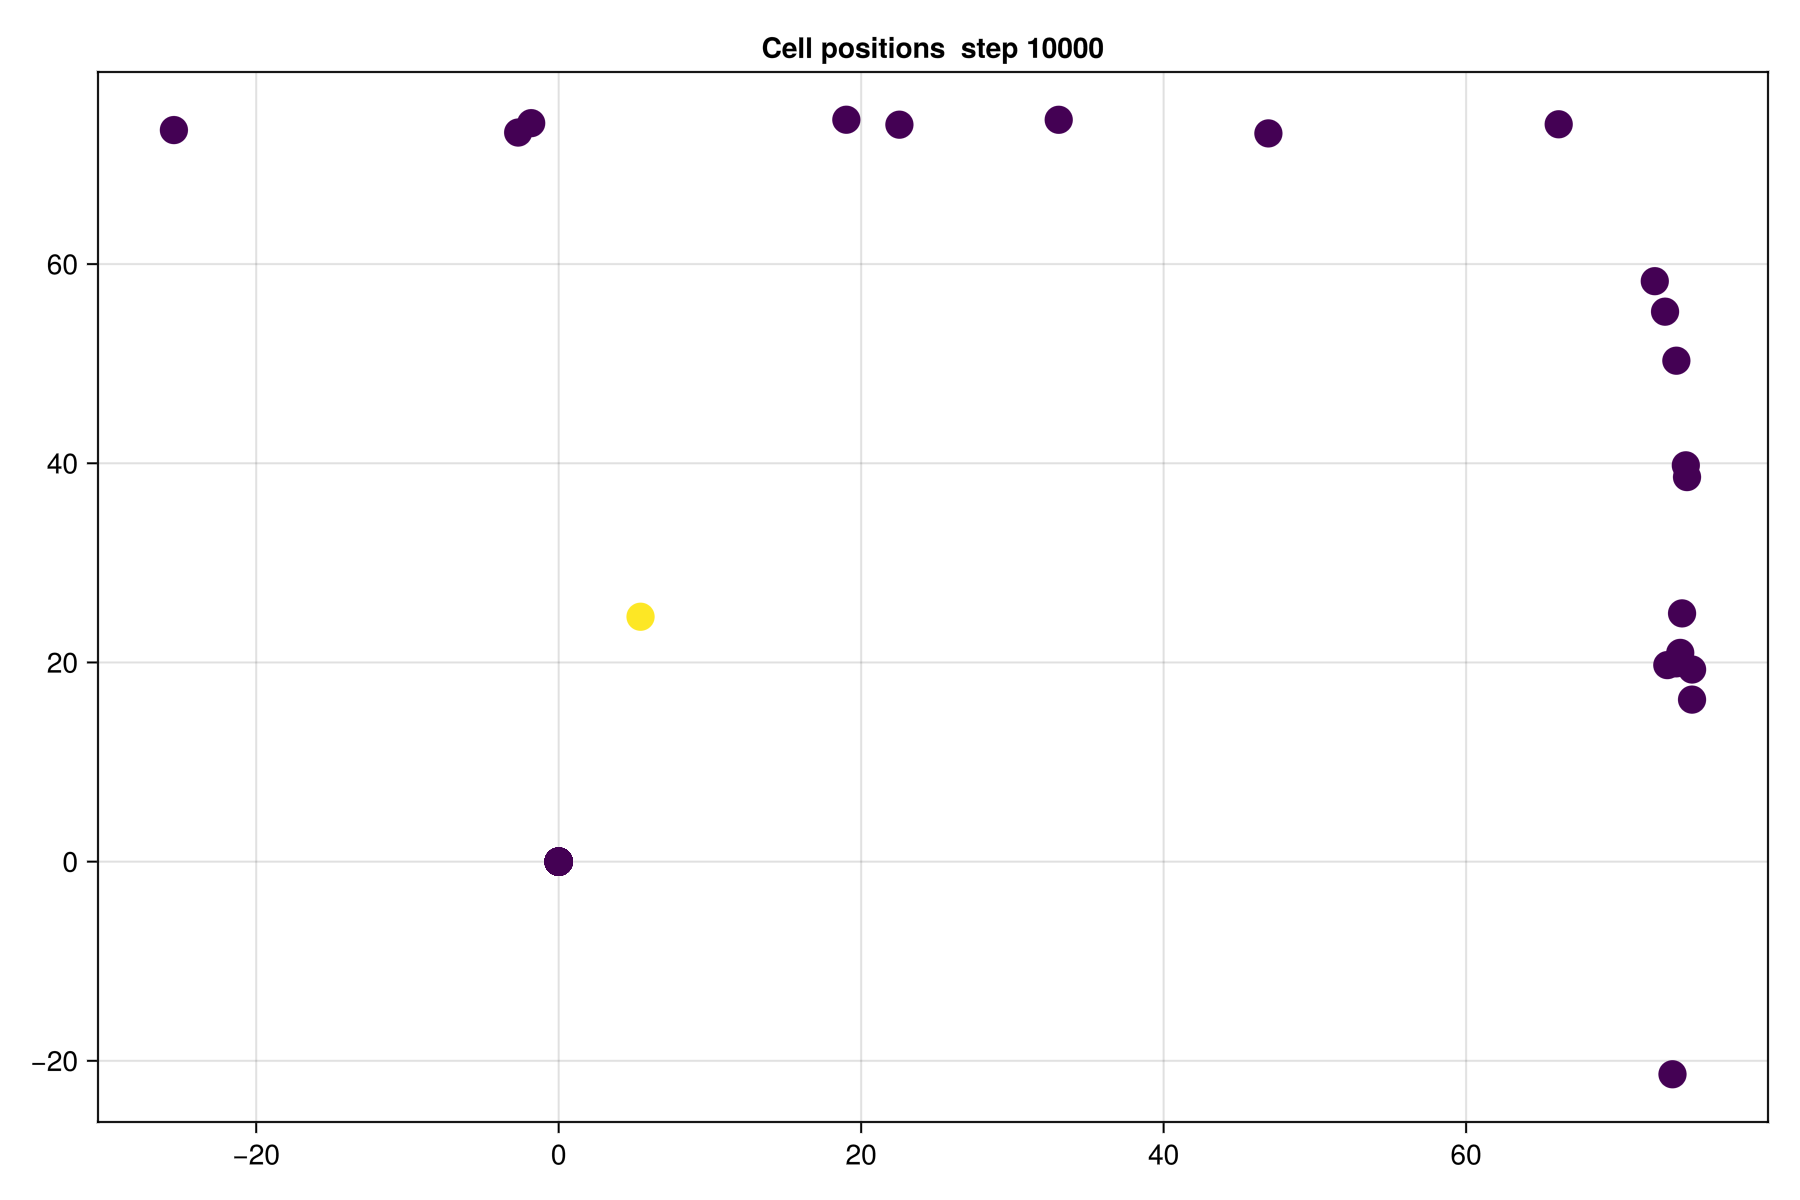

GLMakie.Screen(...)

In [ ]:
fig = Figure(size = (900,600))
ax = Axis(fig[1,1], title ="Cell positions  step 10000")

jldopen("prey_test_with_agents.jld2", "r") do file
    g = file[@sprintf("step_%06d", steps)]     #Plot carrega les posicions de totes les cèl·lules en un punt concret. 

    x = g["x"]
    y = g["y"]
    s = g["isSource"]

    scatter!(ax, x, y, markersize = 20, color = s)
end
display(fig)




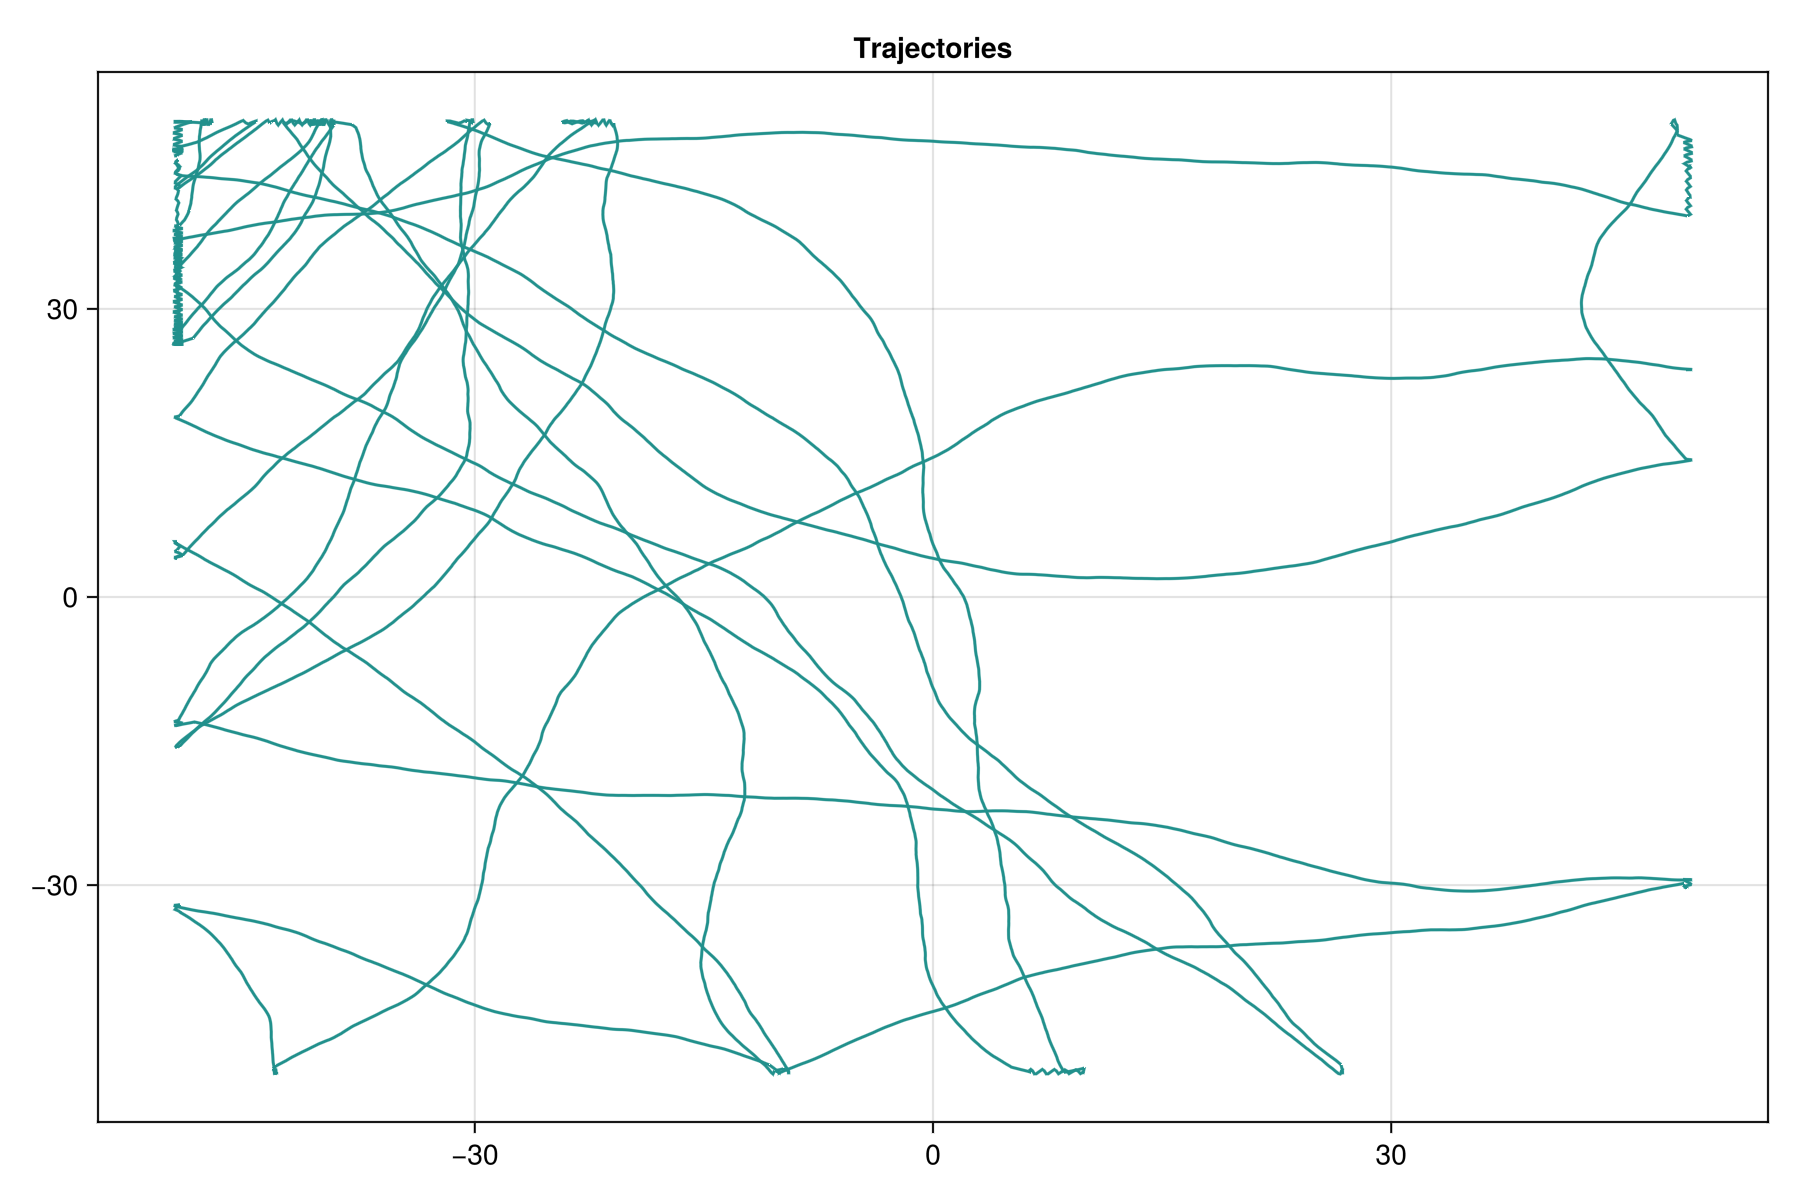

GLMakie.Screen(...)

In [135]:
fig1 = Figure(size = (900,600))
ax1 = Axis(fig1[1,1], title = "Trajectories")

agent = 2     #Trajectory of this agent
traj_x = Vector{Float64}(undef, steps)
traj_y = Vector{Float64}(undef, steps)
s = Vector{Float64}(undef, steps)

jldopen("prey_test_with_agents.jld2", "r") do file 
    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]
        traj_x[step] = g["x"][agent]
        traj_y[step] = g["y"][agent]

    end
end

lines!(ax1, traj_x, traj_y, color = 1)
display(fig1)

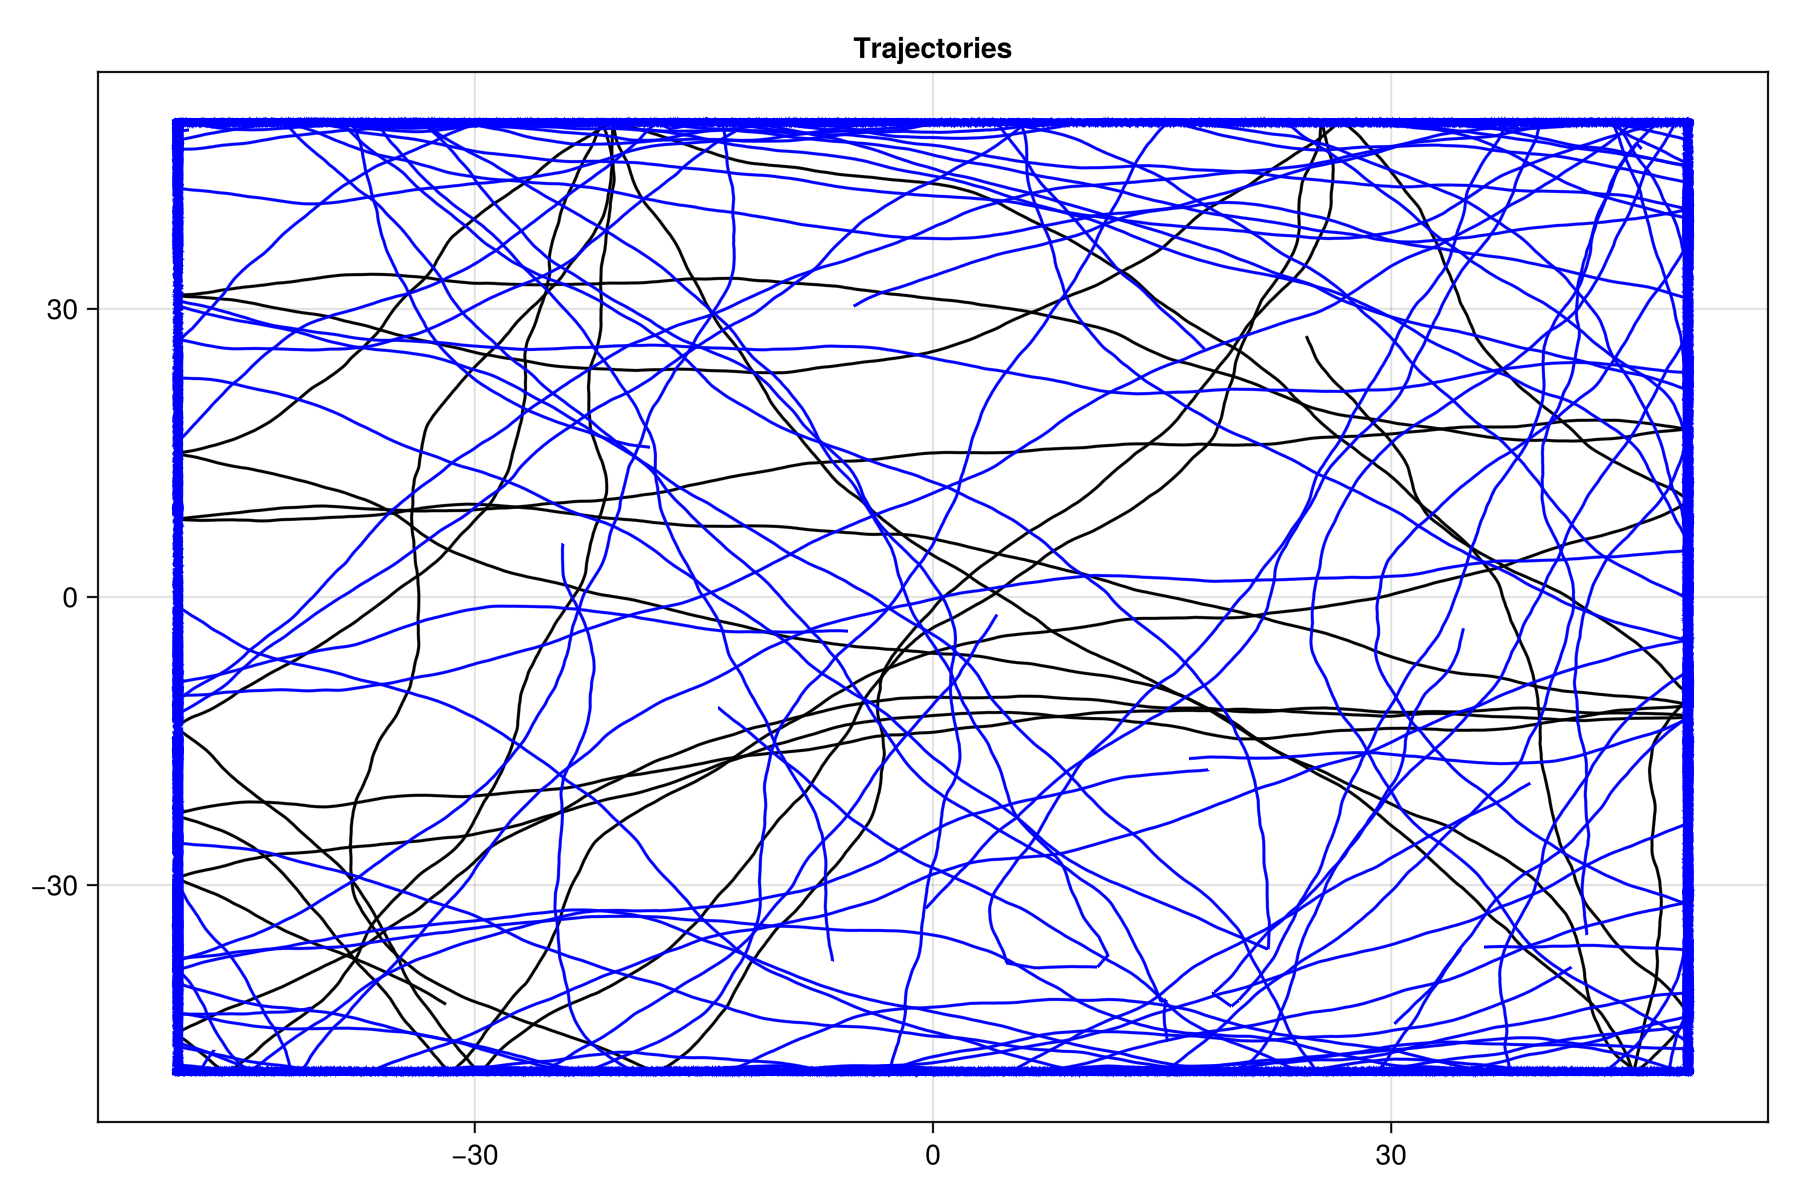

GLMakie.Screen(...)

In [172]:
fig2 = Figure(size = (900,600))
ax2 = Axis(fig2[1,1], title = "Trajectories")


traj_x = Vector{Float64}(undef, steps)
traj_y = Vector{Float64}(undef, steps)
s = Vector{Float64}(undef, steps)

jldopen("prey_test_with_agents.jld2", "r") do file 
    for agent in 1:21
        traj_x = Vector{Float64}(undef, steps)
        traj_y = Vector{Float64}(undef, steps)

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]
            
            traj_x[step] = g["x"][agent]
            traj_y[step] = g["y"][agent]

            s[step] = g["isSource"][agent]

        end

        if s[1] == true

            lines!(ax2, traj_x, traj_y, color = "black")
        else 
            lines!(ax2, traj_x, traj_y, color = "blue")
        end
    
    end 
end
display(fig2)

In [122]:
save("source_agents_tracks.png", fig2)

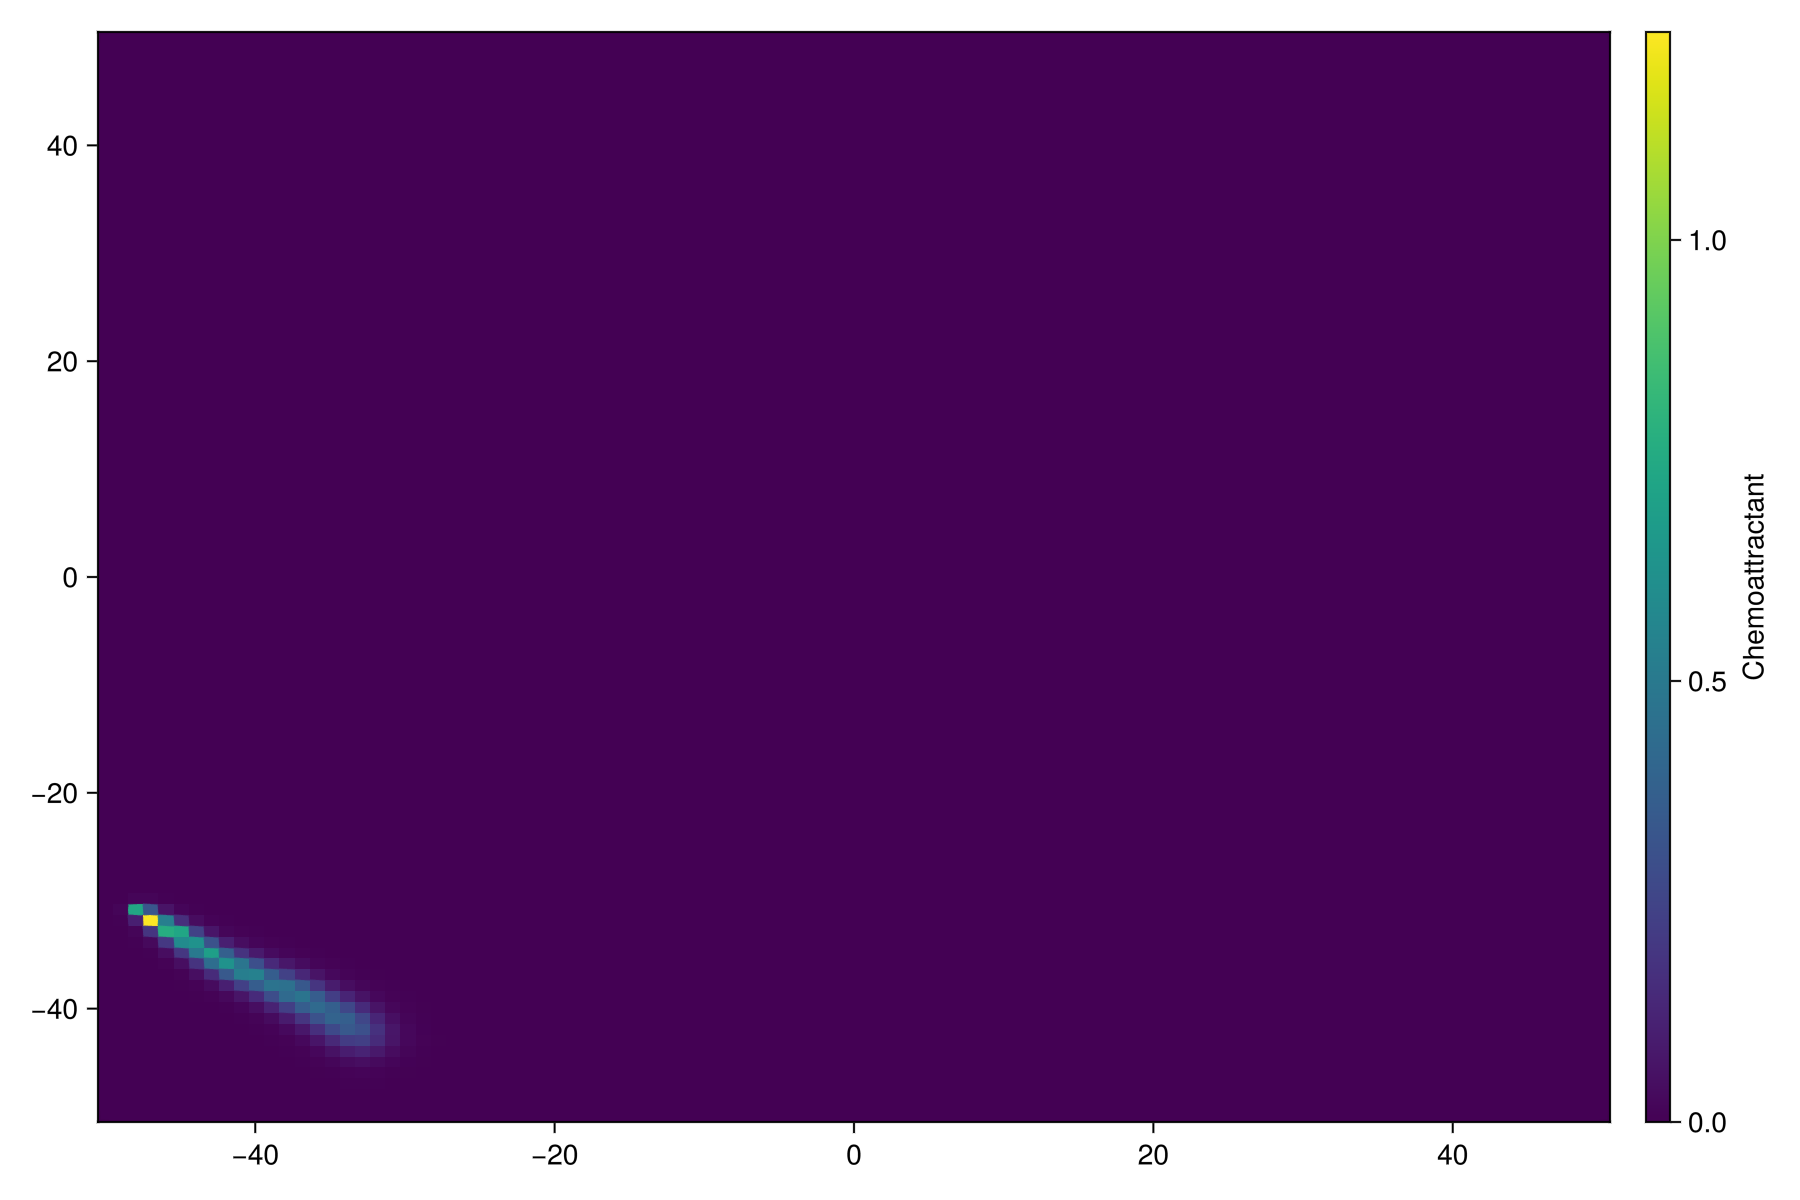

GLMakie.Screen(...)

In [173]:
fig3 = Figure(size = (900,600))
ax3 = Axis(fig3[1,1])

jldopen("prey_test_with_agents.jld2", "r") do file 
    g = file[@sprintf("step_%06d", 100)]

    mm_grid = g["mm_grid"]
    mm = reshape(mm_grid, (100,100))

    hm = heatmap!(ax3, 
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                mm_grid, 
                colormap=:viridis
                )
    Colorbar(fig3[1, 2], hm, label="Chemoattractant")
end

display(fig3)

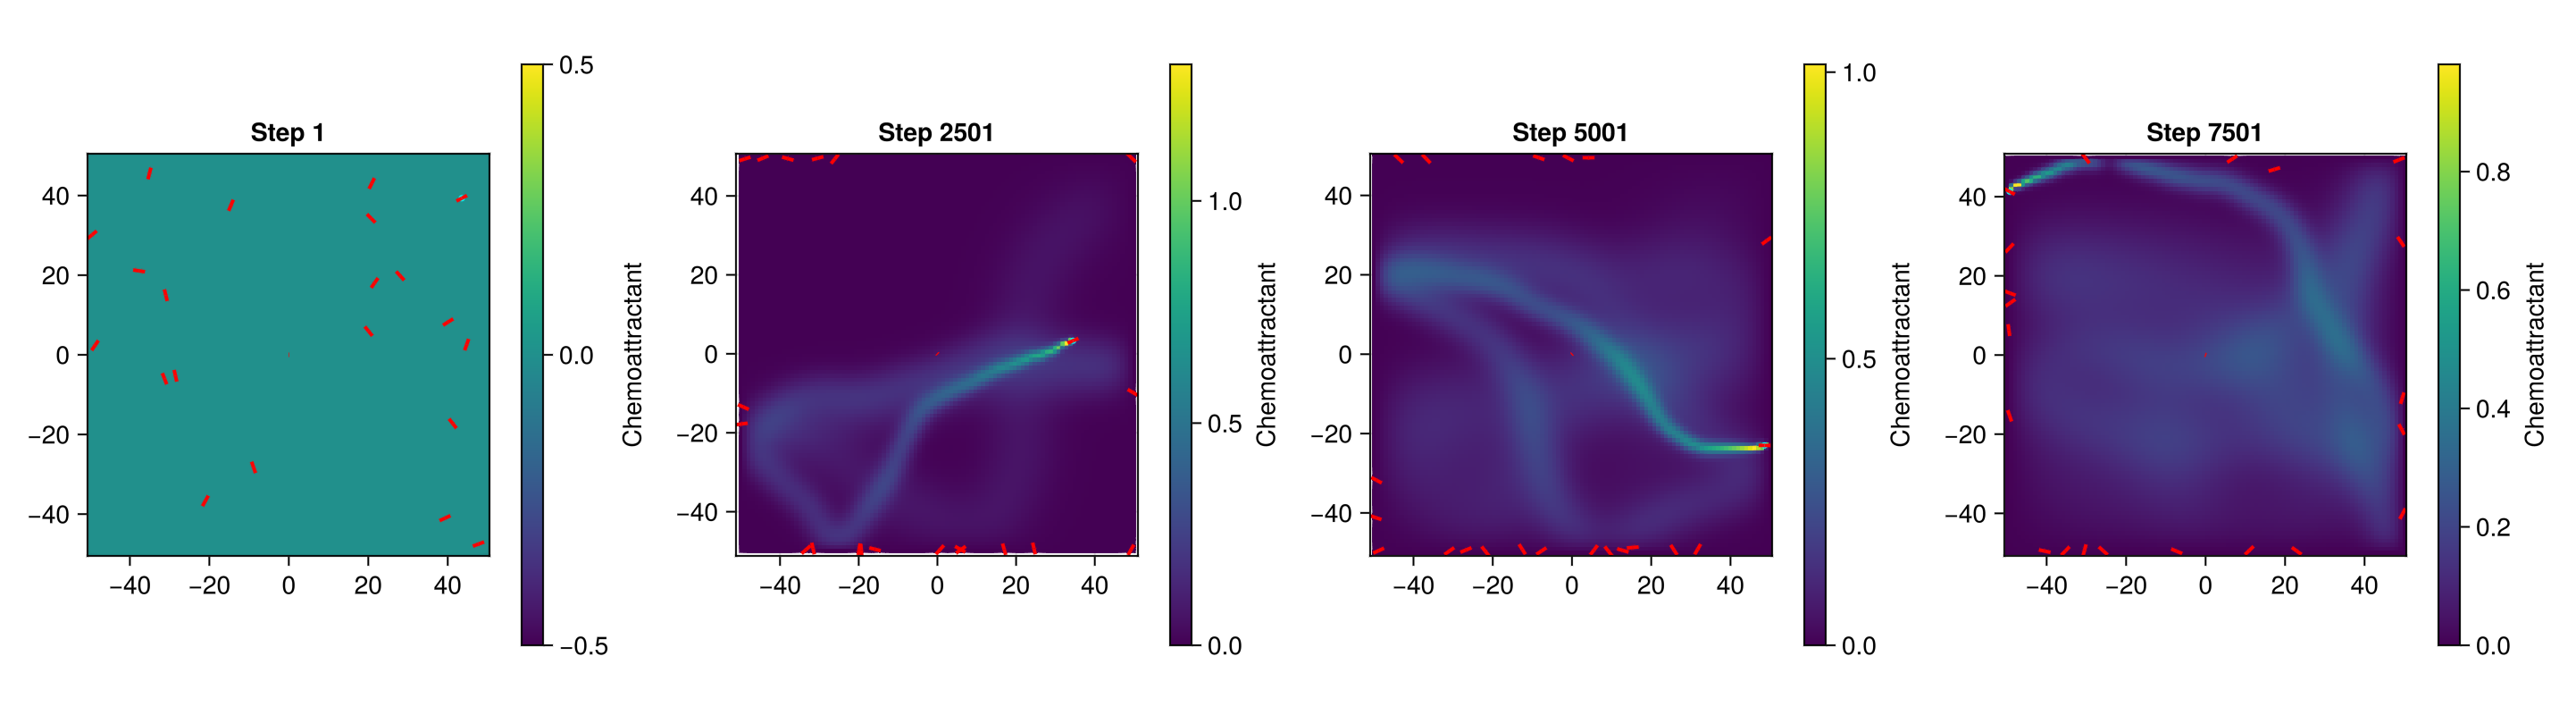

GLMakie.Screen(...)

In [206]:
fig4 = Figure(size=(1800,400))

model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]

jldopen("prey_test_with_agents.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig4[1, 2*j-1], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (100,100))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = g["l"]
                
        scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

        Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

In [114]:
save("source_agent_moving.png", fig4)

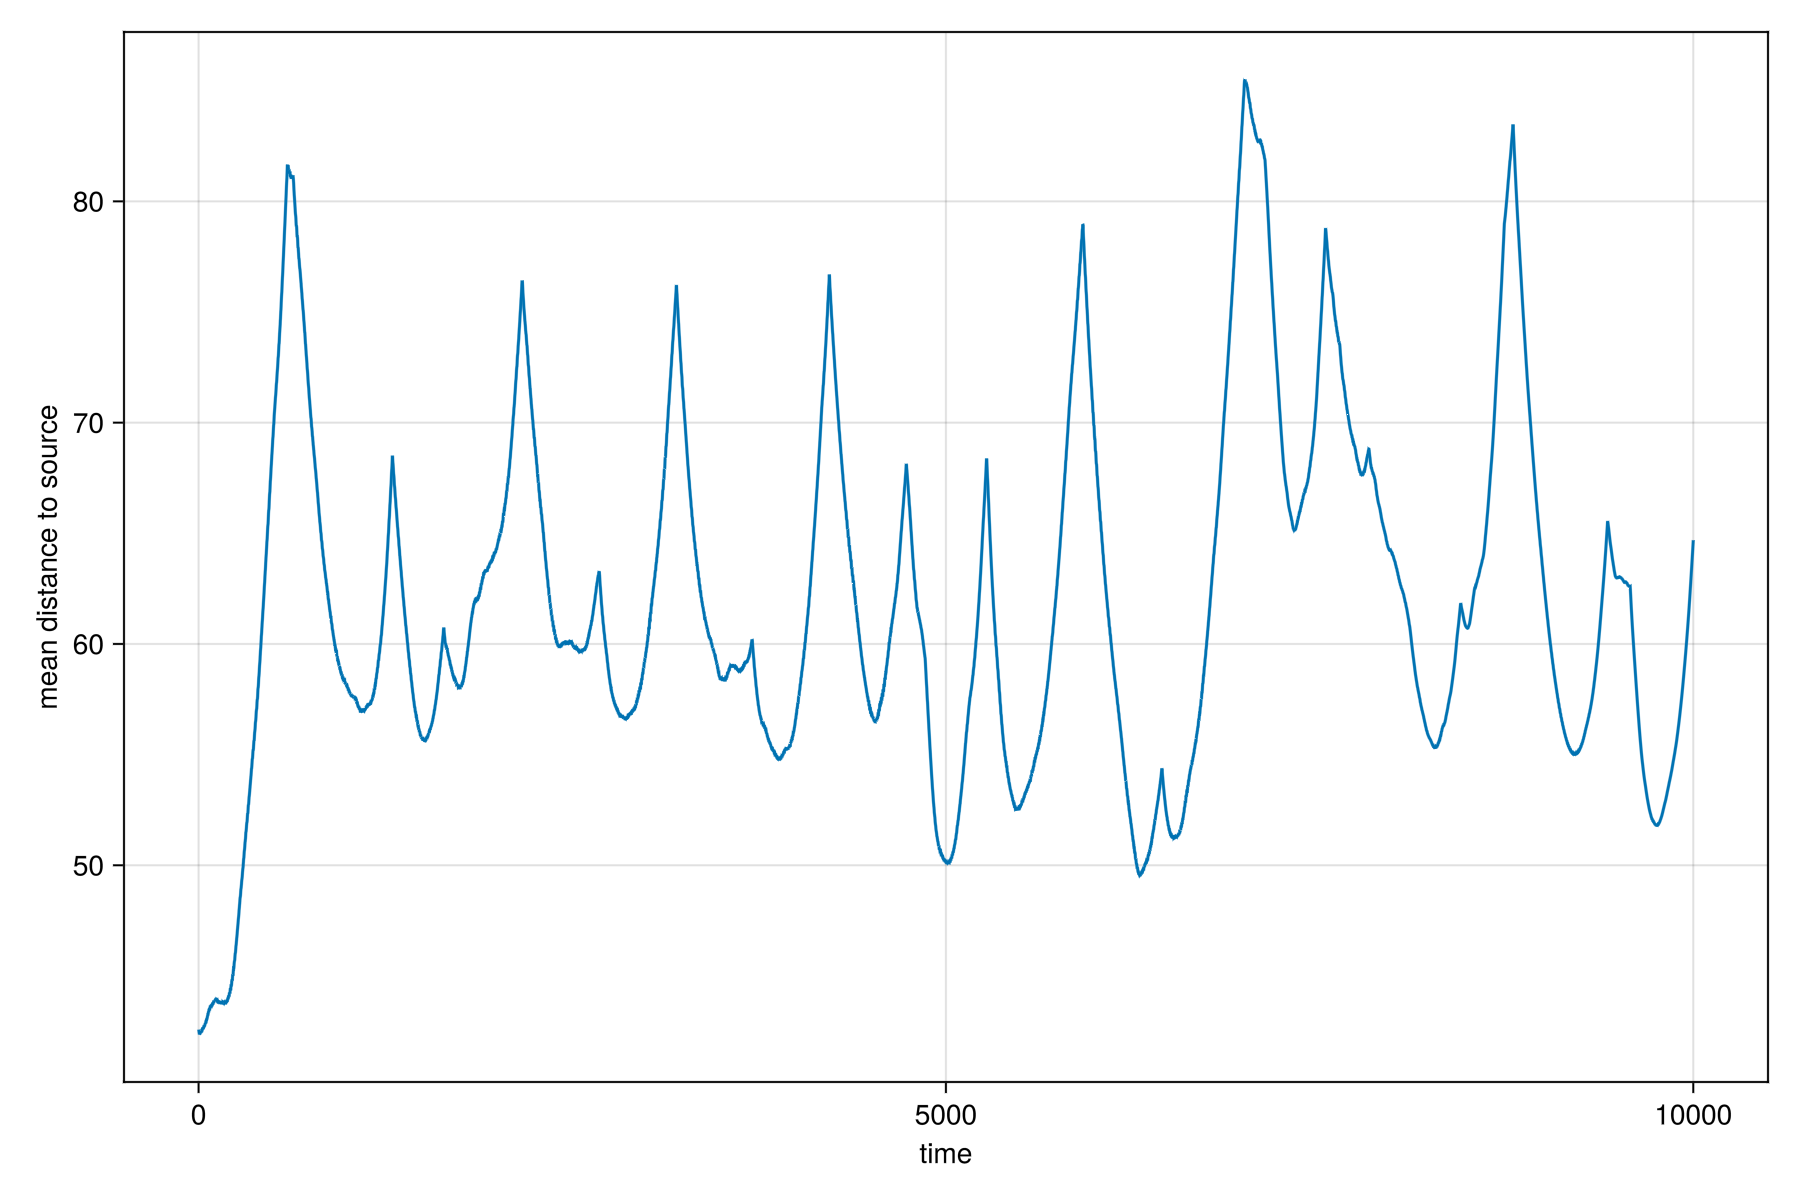

GLMakie.Screen(...)

In [183]:
fig = Figure(size=(900, 600))
ax1 = Axis(fig[1,1], xlabel="time", ylabel="mean distance to source")

mean_dist = Float64[] 

jldopen("prey_test_with_agents.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:21]
        other_y = g["y"][2:21]

        dists = sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2)

        push!(mean_dist, mean(dists))

    end

    lines!(ax1, 1:steps, mean_dist)
end
display(fig)

In [116]:
save("source_agents_medi_dist.png", fig)

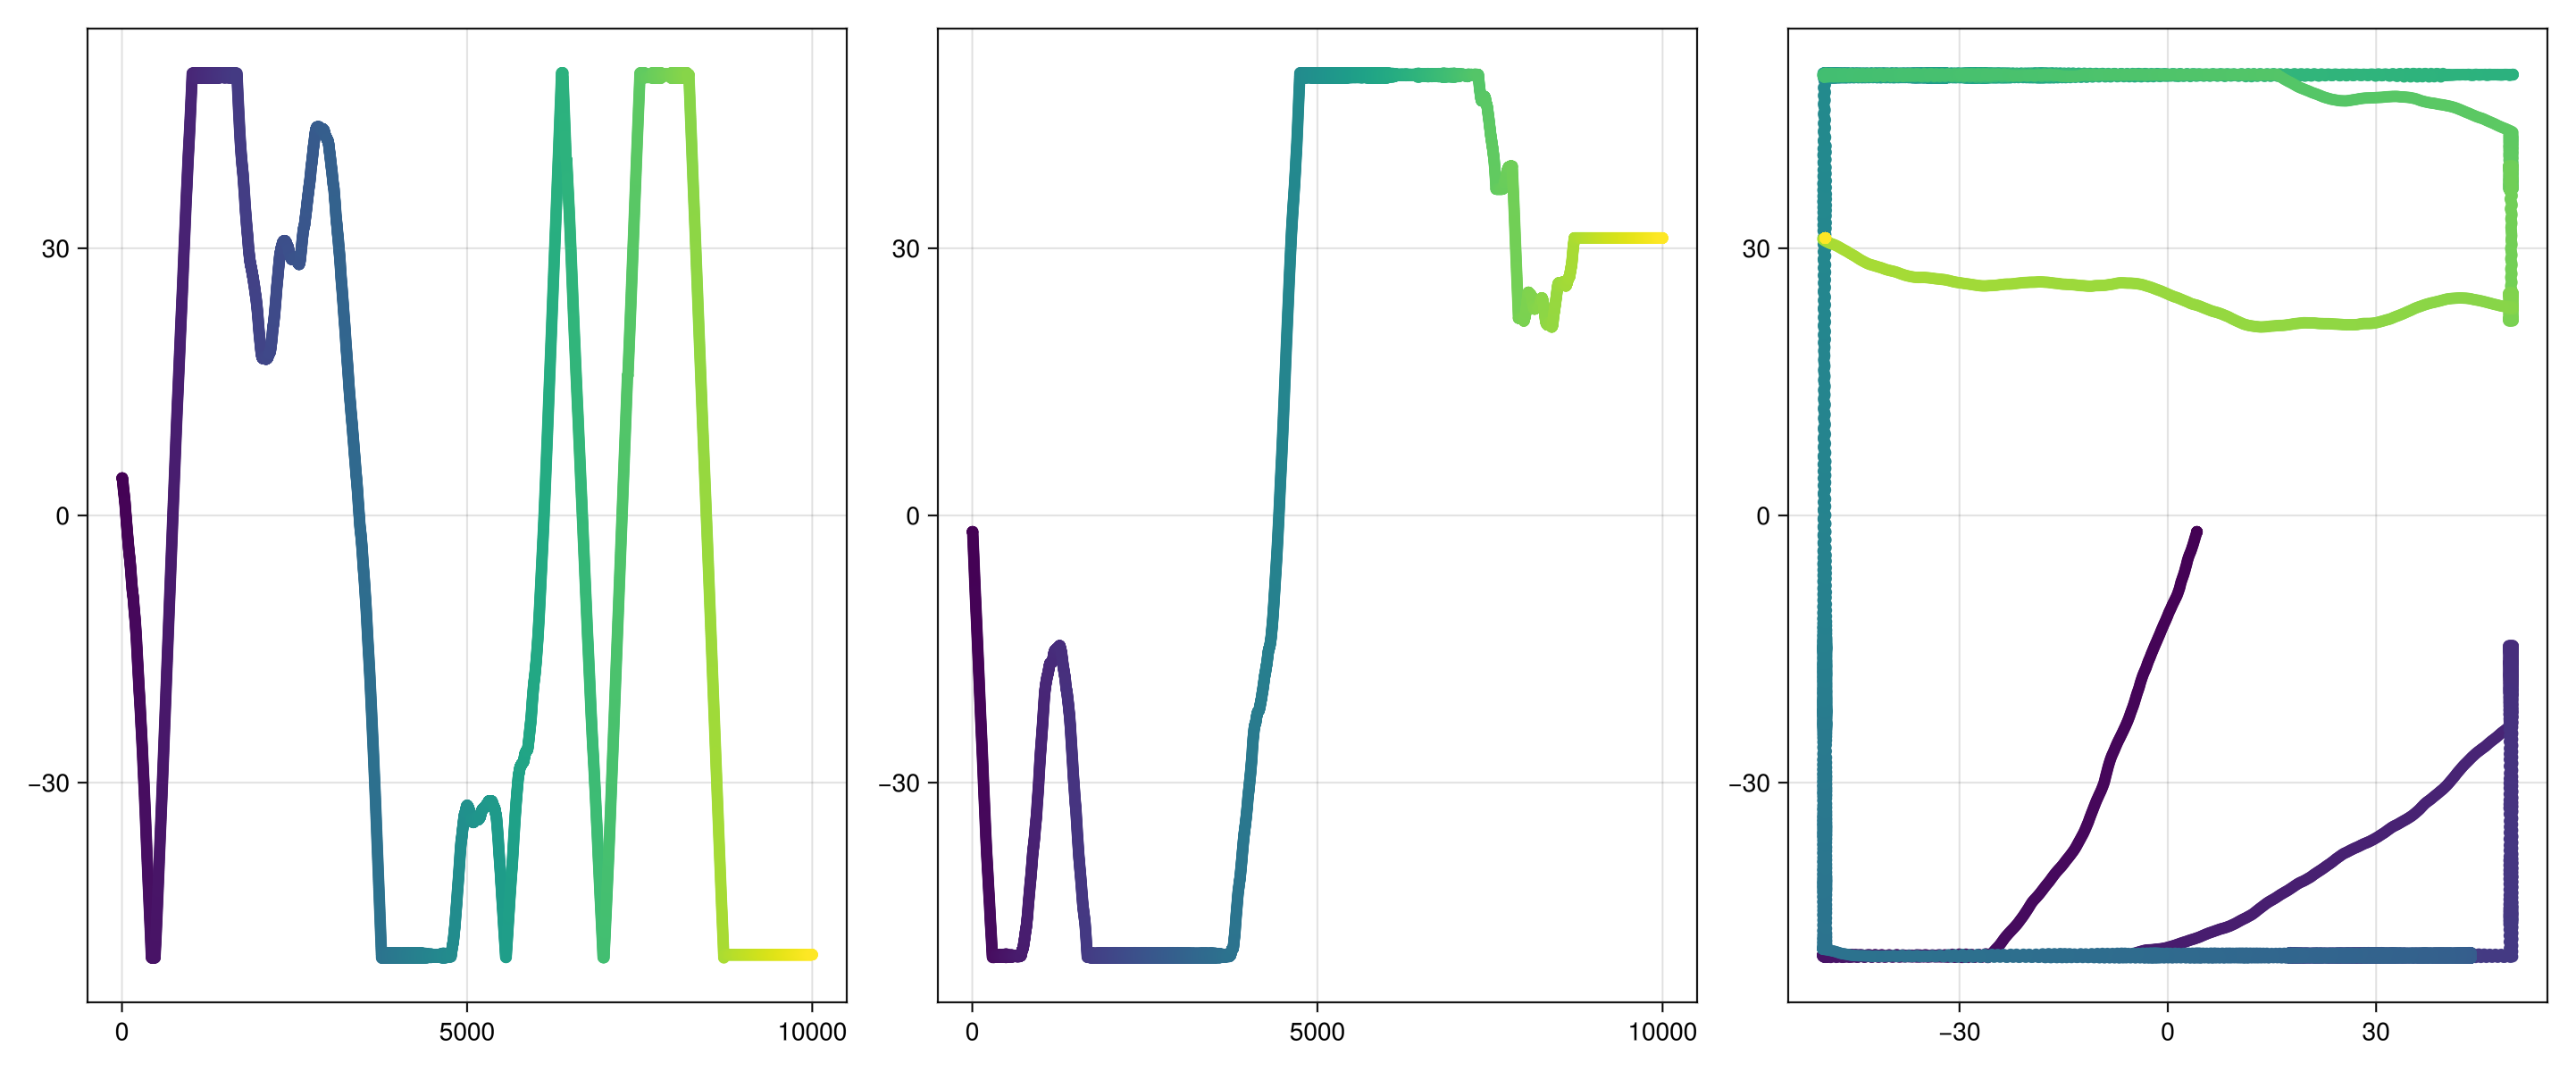

GLMakie.Screen(...)

In [177]:
fig = Figure(size=(2000, 600))

ax = Axis(fig[1,1])
ax2 = Axis(fig[1,2])
ax3 = Axis(fig[1,3])

traj_x = Vector{Float64}(undef, 10000)
traj_y = Vector{Float64}(undef, 10000)

jldopen("prey_test_with_agents.jld2", "r") do file
    for step in 1:10000
        g = file[@sprintf("step_%06d", step)]
            
        traj_x[step] = g["x"][3]
        traj_y[step] = g["y"][3]

    end

    scatter!(ax, 1:10000, traj_x, color = 1:10000)

    scatter!(ax2, 1:10000, traj_y, color = 1:10000)

    scatter!(ax3, traj_x, traj_y, color = 1:10000)
end

display(fig)

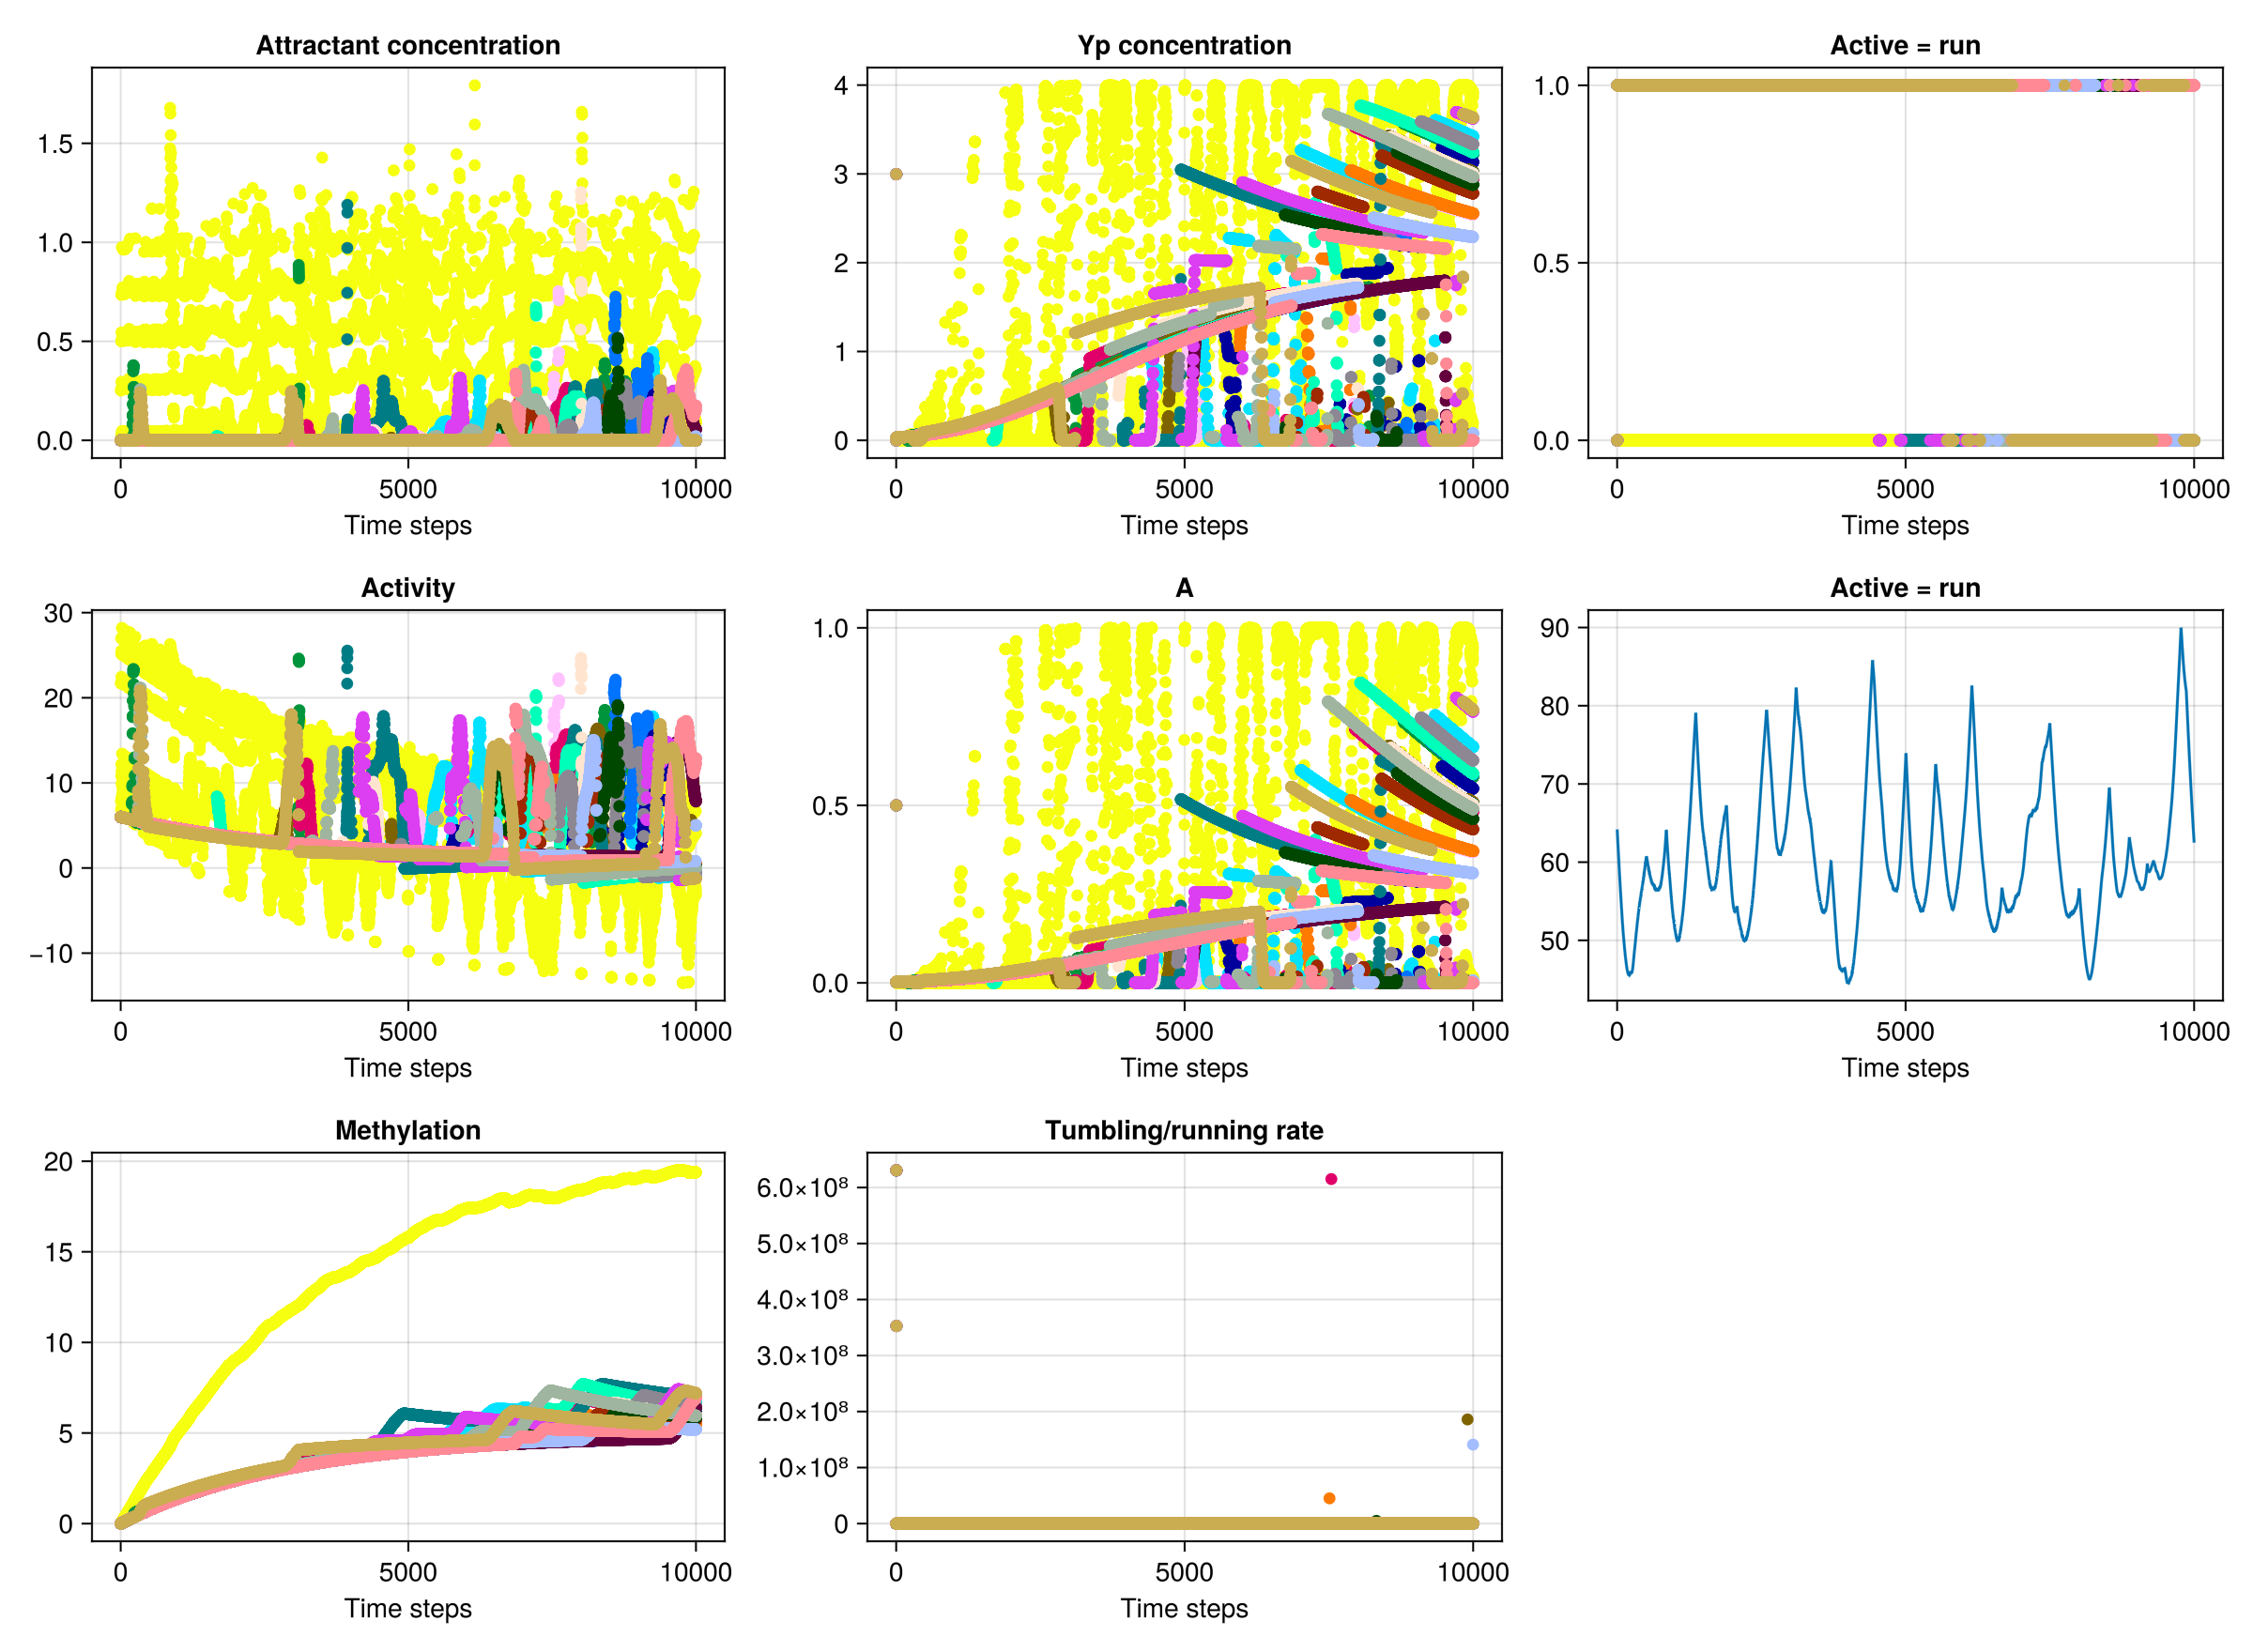

GLMakie.Screen(...)

In [ ]:
using Colors
fig = Figure(size = (1200, 2500))

cell_ids = 1:21
n_cells = length(cell_ids)

# Generate fixed, distinguishable colors (same for all plots)
colors = distinguishable_colors(n_cells, [RGBf(0.2, 0.2, 0.2)], dropseed = true)

# Map id → color
id_to_color = Dict(cell_ids .=> colors)

ax0 = Axis(fig[1,1], title = "Attractant concentration", xlabel = "Time steps")

mm = Vector{Float64}(undef, steps)
jldopen("prey_test_with_agents.jld2", "r") do file 
    for agent in 1:21
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            mm[step] = g["M"][agent]

        end
        scatter!(ax0, 1:steps, mm,  color = id_to_color[agent], label = "Cell $agent")
    end
end

ax1 = Axis(fig[2,1], title = "Activity", xlabel = "Time steps")

F = Vector{Float64}(undef, steps)
jldopen("prey_test_with_agents.jld2", "r") do file 
    for agent in 1:21
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            F[step] = g["F"][agent]

        end
        scatter!(ax1, 1:steps, F,  color = id_to_color[agent], label = "Cell $agent")
    end
end

ax2 = Axis(fig[3,1], title = "Methylation", xlabel = "Time steps")

met = Vector{Float64}(undef, steps)
jldopen("prey_test_with_agents.jld2", "r") do file 
    for agent in 1:21
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            met[step] = g["methyl"][agent]

        end
        scatter!(ax2, 1:steps, met,  color = id_to_color[agent], label = "Cell $agent")
    end
end

ax3 = Axis(fig[1,2], title = "Yp concentration", xlabel = "Time steps")

Y = Vector{Float64}(undef, steps)
jldopen("prey_test_with_agents.jld2", "r") do file 
    for agent in 1:21
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            Y[step] = g["Yp"][agent]

        end
        scatter!(ax3, 1:steps, Y,  color = id_to_color[agent], label = "Cell $agent")
    end
end

ax4 = Axis(fig[2,2], title = "A", xlabel = "Time steps")

A = Vector{Float64}(undef, steps)
jldopen("prey_test_with_agents.jld2", "r") do file 
    for agent in 1:21
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            A[step] = g["A"][agent]

        end
        scatter!(ax4, 1:steps, A,  color = id_to_color[agent], label = "Cell $agent")
    end
end

ax5 = Axis(fig[3,2], title = "Tumbling/running rate", xlabel = "Time steps")

rate = Vector{Float64}(undef, steps)
jldopen("prey_test_with_agents.jld2", "r") do file 
    for agent in 1:21
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            rate[step] = g["λ"][agent]

        end
        scatter!(ax5, 1:steps, rate,  color = id_to_color[agent], label = "Cell $agent")
    end
end

ax6 = Axis(fig[1,3], title = "Active = run", xlabel = "Time steps")

active = Vector{Float64}(undef, steps)
jldopen("prey_test_with_agents.jld2", "r") do file 
    for agent in 1:21
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            active[step] = g["active"][agent]

        end
        scatter!(ax6, 1:steps, active,  color = id_to_color[agent], label = "Cell $agent")
    end
end

ax7 = Axis(fig[2,3], title = "Mean distance to source", xlabel = "Time steps")
mean_dist = []
jldopen("prey_test_with_agents.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:21]
        other_y = g["y"][2:21]

        dists = sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2)

        push!(mean_dist, mean(dists))

    end

    lines!(ax7, 1:steps, mean_dist)
end

# fig[3,3] = Legend(fig, ax0)

display(fig)

## Ensemble graphs

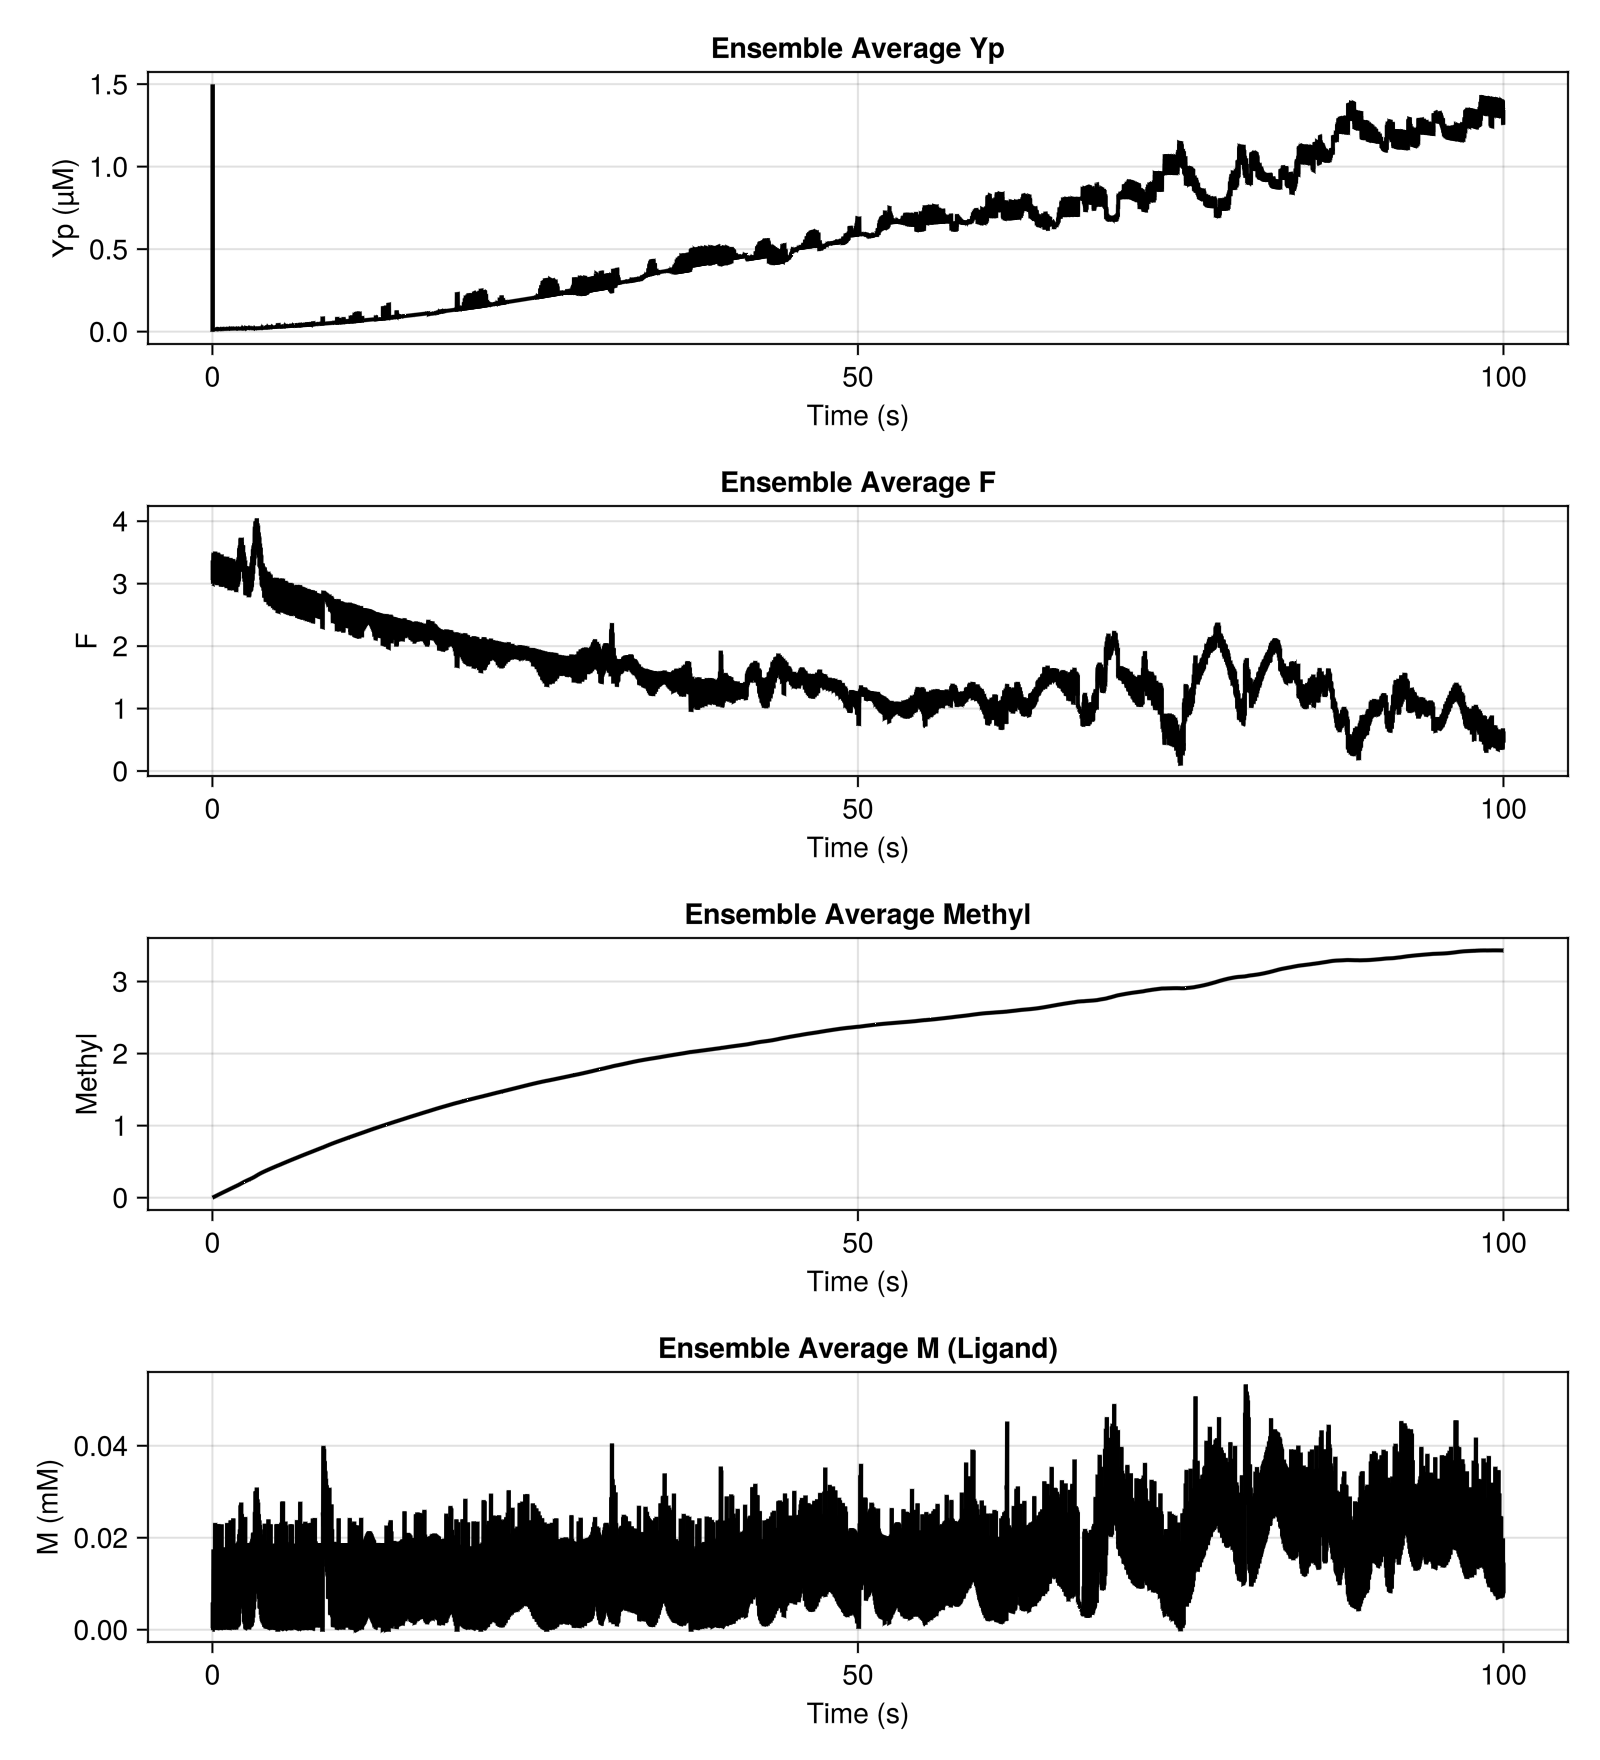

GLMakie.Screen(...)

In [205]:
fig = Figure(size=(800, 1000))
ax1 = Axis(fig[1,1], title="Ensemble Average Yp", xlabel="Time (s)", ylabel="Yp (µM)")
ax2 = Axis(fig[2,1], title="Ensemble Average F", xlabel="Time (s)", ylabel="F")
ax3 = Axis(fig[3,1], title="Ensemble Average Methyl", xlabel="Time (s)", ylabel="Methyl")
ax4 = Axis(fig[4,1], title="Ensemble Average M (Ligand)", xlabel="Time (s)", ylabel="M (mM)")

Yp_mean = Vector{Float64}(undef, steps)
F_mean = Vector{Float64}(undef, steps)
methyl_mean = Vector{Float64}(undef, steps)
M_mean = Vector{Float64}(undef, steps)

jldopen("prey_test_with_agents.jld2", "r") do file 
    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        Yp_mean[step] = mean(g["Yp"])
        F_mean[step] = mean(g["F"])
        methyl_mean[step] = mean(g["methyl"])
        M_mean[step] = mean(g["M"])

    end

    time = (1:steps) .* 0.01

    lines!(ax1, time, Yp_mean, color=:black, linewidth=2)
    lines!(ax2, time, F_mean, color=:black, linewidth=2)
    lines!(ax3, time, methyl_mean, color=:black, linewidth=2)
    lines!(ax4, time, M_mean, color=:black, linewidth=2)
end

display(fig)


In [ ]:
fig = Figure(size=(800, 1000))

# Yp
ax1 = Axis(fig[1,1], title="Ensemble Average Yp", xlabel="Time (s)", ylabel="Yp (µM)")
lines!(ax1, ensemble.t, ensemble.Yp_mean, color=:black, linewidth=2)
band!(ax1, ensemble.t, ensemble.Yp_mean .- ensemble.Yp_sem, ensemble.Yp_mean .+ ensemble.Yp_sem, color=(:blue, 0.2))

# F
ax2 = Axis(fig[2,1], title="Ensemble Average F", xlabel="Time (s)", ylabel="F")
lines!(ax2, ensemble.t, ensemble.F_mean, color=:black, linewidth=2)
band!(ax2, ensemble.t, ensemble.F_mean .- ensemble.F_sem, ensemble.F_mean .+ ensemble.F_sem, color=(:red, 0.2))

# methyl
ax3 = Axis(fig[3,1], title="Ensemble Average Methyl", xlabel="Time (s)", ylabel="Methyl")
lines!(ax3, ensemble.t, ensemble.methyl_mean, color=:black, linewidth=2)
band!(ax3, ensemble.t, ensemble.methyl_mean .- ensemble.methyl_sem, ensemble.methyl_mean .+ ensemble.methyl_sem, color=(:green, 0.2))

# x (position)
ax4 = Axis(fig[4,1], title="Ensemble Average x", xlabel="Time (s)", ylabel="x (µm)")
lines!(ax4, ensemble.t, ensemble.x_mean, color=:black, linewidth=2)
band!(ax4, ensemble.t, ensemble.x_mean .- ensemble.x_sem, ensemble.x_mean .+ ensemble.x_sem, color=(:purple, 0.2))

# M (ligand concentration)
ax5 = Axis(fig[5,1], title="Ensemble Average M (Ligand)", xlabel="Time (s)", ylabel="M (mM)")
lines!(ax5, ensemble.t, ensemble.M_mean, color=:black, linewidth=2)
band!(ax5, ensemble.t, ensemble.M_mean .- ensemble.M_sem, ensemble.M_mean .+ ensemble.M_sem, color=(:orange, 0.2))

display(fig)

# Once difusion loaded for that agent, take that grid matrix for other agents. 


In [40]:
function grid_value(mm, x, y, dx, dy)
    i = clamp(Int(floor(x / dx)) + 1, 1, size(mm,1))
    j = clamp(Int(floor(y / dy)) + 1, 1, size(mm,2))
    return mm[i, j]
end

grid_value (generic function with 1 method)

In [2]:
@inline function grid_value(mm::AbstractMatrix, x, y, dx, dy)
    if !isfinite(x) || !isfinite(y) || dx <= 0 || dy <= 0
        return 0.0
    end

    Nx, Ny = size(mm)
    i = clamp(Int(floor(x / dx)) + 1, 1, Nx)
    j = clamp(Int(floor(y / dy)) + 1, 1, Ny)

    return mm[i, j]
end

grid_value (generic function with 1 method)

In [3]:
rods2DChemotaxis_test = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64

        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,          #Basa Yp leak
        :mm_grid => Matrix{Float64}

    ),

    agentODE = quote        
        
        mm = grid_value(mm_grid, x, y, dx, dy)

        M = mm


        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = active * vx  #Change position acording to constant speed afected by forces
        dt(y) = active * vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
     
        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed
                vy = speed
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        elseif !active
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed
                vy = speed
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end

        collision = (x ≤ simBox[1,1]) || (x ≥ simBox[1,2]) || (y ≤ simBox[2,1]) || (y ≥ simBox[2,2])

        if collision
            vx = v_tumble
            vy = v_tumble
            theta = rand(Uniform(0, 2π))
        end


    end,

    # mediumODE = quote
    #     if @mediumInside()
    #         dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm 
    #     elseif @mediumBorder(1,-1)
    #         mm = 0
    #     elseif @mediumBorder(1,1)
    #         mm = 0
    #     elseif @mediumBorder(2,-1)
    #         mm = 0
    #     elseif @mediumBorder(2,-1)
    #         mm = 0
    #     end
    # end,

    neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	F (Float64 agent)
	fx (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	fy (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	mm_grid (Matrix{Float64} model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if active
            v_run
        else
            v_tumble
        end
    Dr_tumble = 6.2
    Dr_total = if

In [4]:
com_test = Community(
    rods2DChemotaxis_test,
    N=20,
    dt=0.01,
    # simBox = [-20.0 20.0; -20.0 20.0],
    simBox = [0 100; 0 100],
    NMedium = [100, 100]
    # NMedium = [200, 200]
)

m = 1/100
g = 1/10000
d = 1

com_test.Dr_run = 0.062

# com_test.v =  0.33   #Velocitat neutrophil (20 microm/min) 
com_test.v = 20.0    #(microm/s)
# com_test.v = 10.0
# com_test.v = 5.0
# com_test.v = 2.5
# com_test.v = 1

com_test.ωFrec = 1.3
com_test.Ki = 0.0182
com_test.Ka = 3.0
com_test.Nrec = 6.0
com_test.ε0   = 6.0
com_test.ε1   = -1.0
com_test.ε2   = 80
com_test.ε3   = 80

# com_test.τm = 5.0
# com_test.τm = 10.0
com_test.τm = 30.0

com_test.α   = 6.0

com_test.K = 2.0 

com_test.Ky = 100.0
com_test.Kz = 10.0
com_test.Z = 5.0
com_test.Yy = 0.1

com_test.m = 1.        
com_test.d = 1.        
com_test.l = 3;

com_test.x = rand(Uniform(com_test.simBox[1,:]...),com_test.N)
com_test.y = rand(Uniform(com_test.simBox[2,:]...),com_test.N)
com_test.theta = rand(Uniform(0,2π),com_test.N)

com_test.methyl .= 0.0
com_test.Yp .= com_test.K

com_test.active .= true 

20-element Vector{Bool}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

In [5]:
outfile = "prey_test_agents.jld2"
steps = 10000

loadToPlatform!(com_test, preallocateAgents=20)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")
    meta["N"] = com_test.N
    meta["NMedium"] = com_test.NMedium
    meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps

        com_test.mm_grid = jldopen("prey_test.jld2", "r") do file
        file[@sprintf("step_%06d/mm_grid", step)]
        end

        step!(com_test)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com_test.x)
        g["y"] = copy(com_test.y)
        g["theta"] = copy(com_test.theta)
        g["l"] = copy(com_test.l)
        g["d"] = copy(com_test.d)
        g["active"] = copy(com_test.active)

        # Medium grid (saved once per step)
        g["mm"] = copy(com_test.M)
    end
end


MethodError: MethodError: no method matching Matrix{Float64}(::Vector{Float64})

Closest candidates are:
  Array{T, N}(::AbstractArray{S, N}) where {T, N, S}
   @ Base array.jl:673
  Array{T, N}(!Matched::Missing, Any...) where {T, N}
   @ Base baseext.jl:43
  Matrix{T}(!Matched::UndefInitializer, !Matched::Tuple{Int64, Int64}) where T
   @ Core boot.jl:487
  ...
